In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error
%matplotlib inline

In [13]:
df=pd.read_csv("multiple_linear_regression.csv")
df.head()

,Experience_Years,Education_Level,Certifications,Salary
0,7,4,4,23975.648233
1,20,4,1,48532.034083
2,15,3,1,28683.347155
3,11,3,2,19604.450061
4,8,1,1,7330.345153


In [14]:
x=df[['Experience_Years','Education_Level','Certifications']]   #x=df.iloc[:,:-1]
y=df['Salary']                                                        #x=df.iloc[:,-1]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [15]:
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [16]:
lr=LinearRegression(n_jobs=-1)
lr.fit(x_train,y_train)

LinearRegression(n_jobs=-1)

In [17]:
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(lr,x_train,y_train,scoring='neg_mean_squared_error',cv=3)
#3 cross validations
-validation_score

array([29907714.25071127, 39675843.47188998, 50115457.56234616])

CROSS_VAL_SCORE():
This function splits your training data into multiple folds (partitions) and evaluates your model on each fold.
It trains the model on (k−1) parts and validates on the remaining 1 part.
Repeats this k times (3 in your case).
So you're getting a score for each fold, to check model performance consistency.

scoring='neg_mean_squared_error'	:Tells sklearn to evaluate using Mean Squared Error (MSE), but it's negated


In [18]:
y_pred=lr.predict(x_test)
mean_absolute_error(y_test,y_pred)
print(mean_absolute_error)

<function mean_absolute_error at 0x00000171C98BF6A0>


In [21]:
lr.predict(sc.transform([[43.708611,6.414313,6.778285]]))

C:\Users\Varshitha\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([72276.56606051])

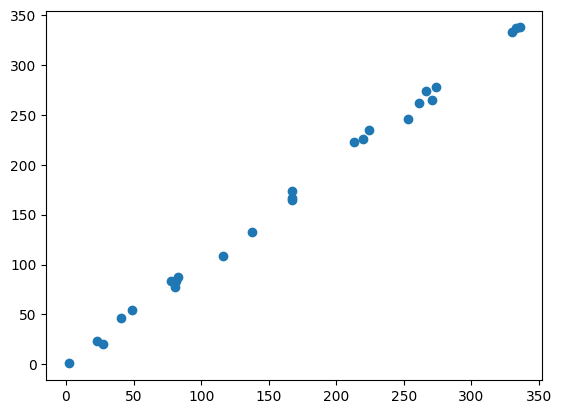

In [ ]:
plt.scatter(y_test,y_pred)

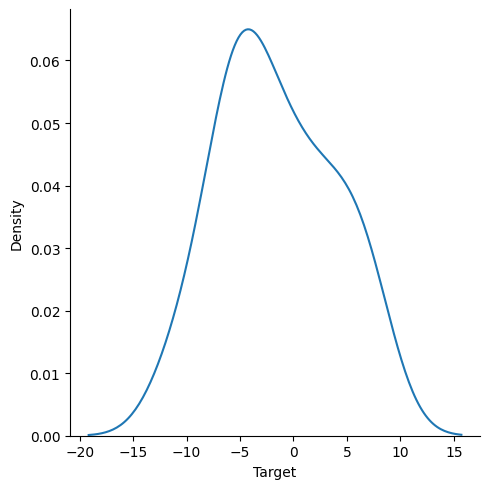

In [ ]:
residuals=y_test-y_pred
sns.displot(residuals,kind='kde')

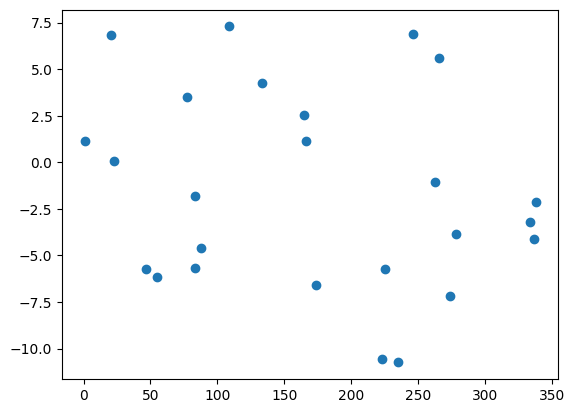

In [ ]:
plt.scatter(y_pred,residuals)

In [ ]:
import pickle
pickle.dump(lr,open('multiple_regression.pkl','wb'))

In [20]:
model=pickle.load(open('multiple_regression.pkl','rb'))
model.predict(x_test)

array([30646.24446703, 15202.56761739, 32911.69210093, 14621.69617673,
       33392.81227848, 38548.83074433, 30591.40053311, 25019.69800017,
       22819.68647673, 24373.39044904, 22207.69407825, 24493.67049343,
       27789.98878773, 36414.25533136, 21932.81883683, 17457.42307475,
       21932.81883683, 21025.42241565, 16055.12010465, 18464.57075904,
       12947.71216003, 16756.2715897 , 33908.24760868, 22207.69407825,
       29092.54049472])